In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/media/admin/Expansion/Mosaic_Data_for_Ipeks_Group/OCT_Inpainting_Testing/inpainting_ablation_metrics.csv")
df.head()

,LossType,Augment,MaskedLoss,StackSize,Fold,InpaintMethod,L1,SSIM,MeanIntensityError
0,global,False,False,5,0,original,0.0137,0.7667,0.0001
1,global,False,False,5,0,outsidein,0.0136,0.7673,0.0001
2,global,False,False,5,1,original,0.0136,0.7901,0.0001
3,global,False,False,5,1,outsidein,0.0134,0.7931,0.0002
4,global,False,False,5,2,original,0.0120,0.7991,0.0000


### Group-wise Summaries

In [3]:
summary = df.groupby(["LossType", "Augment", "MaskedLoss", "StackSize", "InpaintMethod"]).mean(numeric_only=True)

In [9]:
print(summary.sort_values("L1"))

                                                             Fold       L1  \
LossType         Augment MaskedLoss StackSize InpaintMethod                  
brightness_aware True    False      9         original        2.0  0.01356   
global           False   False      9         original        2.0  0.01356   
brightness_aware True    False      9         outsidein       2.0  0.01358   
global           True    False      13        original        2.0  0.01362   
brightness_aware False   False      9         original        2.0  0.01364   
global           True    False      13        outsidein       2.0  0.01366   
brightness_aware False   False      13        original        2.0  0.01368   
                                    9         outsidein       2.0  0.01374   
global           True    False      9         original        2.0  0.01374   
                 False   False      13        original        2.0  0.01382   
                 True    False      9         outsidein       2.

In [10]:
print(df.groupby("Augment")[["L1", "SSIM", "MeanIntensityError"]].mean())

               L1      SSIM  MeanIntensityError
Augment                                        
False    0.015227  0.752092            0.000144
True     0.015678  0.740066            0.000201


In [15]:
print(df.groupby("MaskedLoss")[["L1", "SSIM", "MeanIntensityError"]].mean())

                  L1      SSIM  MeanIntensityError
MaskedLoss                                        
False       0.013945  0.769767            0.000106
True        0.016959  0.722392            0.000239


In [16]:
# print(df.groupby(["LossType", "MaskedLoss"])[["L1", "SSIM", "MeanIntensityError"]].mean())

filtered_df = df[df["MaskedLoss"] == False]
print(filtered_df.groupby("LossType")[["L1", "SSIM", "MeanIntensityError"]].mean())

                        L1      SSIM  MeanIntensityError
LossType                                                
brightness_aware  0.013925  0.769612            0.000105
global            0.013965  0.769922            0.000107


In [6]:
print(df.groupby("StackSize")[["L1", "SSIM", "MeanIntensityError"]].mean())

                 L1      SSIM  MeanIntensityError
StackSize                                        
5          0.016076  0.736059            0.000198
9          0.014967  0.753066            0.000163
13         0.015313  0.749113            0.000158


In [18]:
print(df.groupby("InpaintMethod")[["L1", "SSIM", "MeanIntensityError"]].mean())

                     L1      SSIM  MeanIntensityError
InpaintMethod                                        
hybrid         0.017030  0.725575            0.000267
noncorrupted   0.016888  0.719208            0.000212
original       0.013813  0.769945            0.000103
outsidein      0.014077  0.769588            0.000108


In [23]:
import statsmodels.formula.api as smf

# Ensure categorical variables are treated as such
df["LossType"] = df["LossType"].astype("category")
df["Augment"] = df["Augment"].astype("category")
df["MaskedLoss"] = df["MaskedLoss"].astype("category")
df["InpaintMethod"] = df["InpaintMethod"].astype("category")
# df["Fold"] = df["Fold"].astype("category")  # optional: include this if treating fold as a blocking factor

# Fit the linear regression model for L1
model_l1 = smf.ols("L1 ~ C(LossType) + C(Augment) + C(MaskedLoss) + C(StackSize) + C(InpaintMethod)", data=df).fit()

# Print the model summary
print(model_l1.summary())


                            OLS Regression Results                            
Dep. Variable:                     L1   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     24.03
Date:                Tue, 13 May 2025   Prob (F-statistic):           1.83e-24
Time:                        12:34:52   Log-Likelihood:                 1161.2
No. Observations:                 240   AIC:                            -2306.
Df Residuals:                     232   BIC:                            -2279.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

### Visualizations

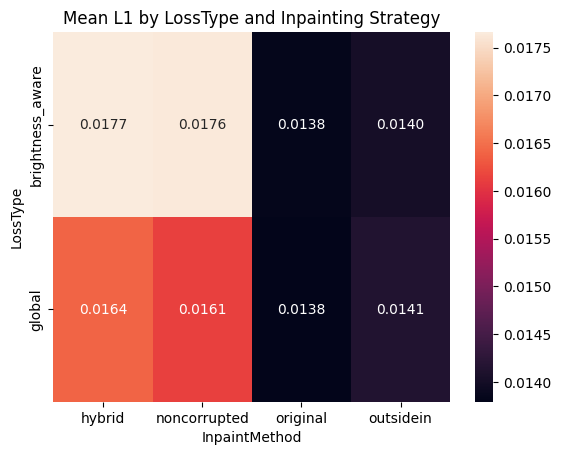

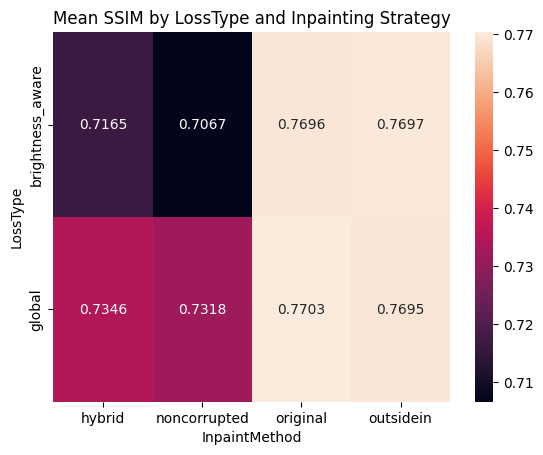

In [9]:
pivot = df.pivot_table(index="LossType", columns="InpaintMethod", values="L1", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".4f")
plt.title("Mean L1 by LossType and Inpainting Strategy")
plt.show()

pivot = df.pivot_table(index="LossType", columns="InpaintMethod", values="SSIM", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".4f")
plt.title("Mean SSIM by LossType and Inpainting Strategy")
plt.show()

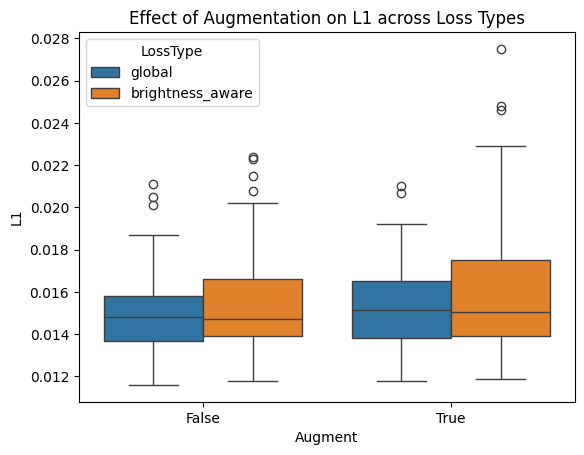

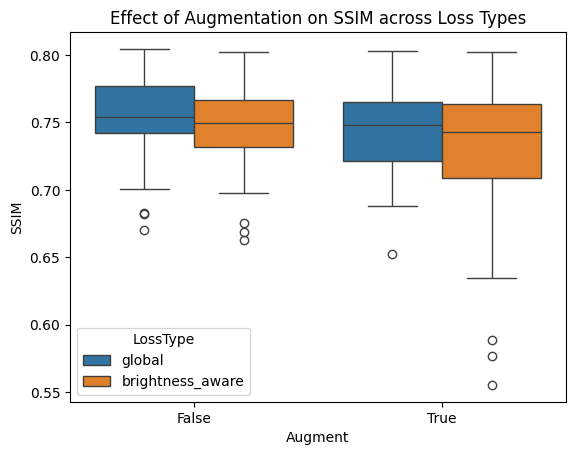

In [10]:
sns.boxplot(data=df, x="Augment", y="L1", hue="LossType")
plt.title("Effect of Augmentation on L1 across Loss Types")
plt.show()

sns.boxplot(data=df, x="Augment", y="SSIM", hue="LossType")
plt.title("Effect of Augmentation on SSIM across Loss Types")
plt.show()

In [11]:
subset = df[(df["LossType"] == "brightness_aware") & (df["InpaintMethod"] == "hybrid")]
print(subset.groupby("Augment")[["L1", "SSIM"]].mean())

               L1      SSIM
Augment                    
False    0.016993  0.731627
True     0.018333  0.701400


### Best-performing Configurations

In [13]:
best_by_l1 = df.sort_values("L1")
print("BEST BY L1:")
print(best_by_l1.head(10))

BEST BY L1:
             LossType  Augment  MaskedLoss  StackSize  Fold InpaintMethod  \
15             global    False       False          9     2     outsidein   
14             global    False       False          9     2      original   
75             global     True       False          9     2     outsidein   
145  brightness_aware    False       False         13     2     outsidein   
144  brightness_aware    False       False         13     2      original   
25             global    False       False         13     2     outsidein   
74             global     True       False          9     2      original   
24             global    False       False         13     2      original   
195  brightness_aware     True       False          9     2     outsidein   
84             global     True       False         13     2      original   

         L1    SSIM  MeanIntensityError  
15   0.0116  0.8045              0.0001  
14   0.0116  0.8037              0.0000  
75   0.0118  0

In [16]:
best_by_ssim = df.sort_values("SSIM", ascending=False)
print("BEST BY SSIM:")
print(best_by_ssim.head(10))

BEST BY SSIM:
             LossType  Augment  MaskedLoss  StackSize  Fold InpaintMethod  \
15             global    False       False          9     2     outsidein   
14             global    False       False          9     2      original   
85             global     True       False         13     2     outsidein   
144  brightness_aware    False       False         13     2      original   
145  brightness_aware    False       False         13     2     outsidein   
195  brightness_aware     True       False          9     2     outsidein   
134  brightness_aware    False       False          9     2      original   
24             global    False       False         13     2      original   
135  brightness_aware    False       False          9     2     outsidein   
84             global     True       False         13     2      original   

         L1    SSIM  MeanIntensityError  
15   0.0116  0.8045              0.0001  
14   0.0116  0.8037              0.0000  
85   0.0121 

In [15]:
best_by_mie = df.sort_values("MeanIntensityError")
print("BEST BY MEAN INTENSITY ERROR:")
print(best_by_mie.head(10))

BEST BY MEAN INTENSITY ERROR:
   LossType  Augment  MaskedLoss  StackSize  Fold InpaintMethod      L1  \
6    global    False       False          5     3      original  0.0146   
7    global    False       False          5     3     outsidein  0.0155   
4    global    False       False          5     2      original  0.0120   
8    global    False       False          5     4      original  0.0155   
14   global    False       False          9     2      original  0.0116   
22   global    False       False         13     1      original  0.0142   
23   global    False       False         13     1     outsidein  0.0142   
19   global    False       False          9     4     outsidein  0.0154   
24   global    False       False         13     2      original  0.0119   
25   global    False       False         13     2     outsidein  0.0119   

      SSIM  MeanIntensityError  
6   0.7494                 0.0  
7   0.7458                 0.0  
4   0.7991                 0.0  
8   0.7404  

In [28]:
# Sort by Fold and SSIM
top_5_per_fold = (
    df.sort_values(["Fold", "SSIM"], ascending=[True, False])
      .groupby("Fold", group_keys=False)
      .head(5)
)

print("TOP 5 BY SSIM FOR EACH FOLD (GROUPED AND ORDERED):")
print(top_5_per_fold)

TOP 5 BY SSIM FOR EACH FOLD (GROUPED AND ORDERED):
             LossType  Augment  MaskedLoss  StackSize  Fold InpaintMethod  \
140  brightness_aware    False       False         13     0      original   
141  brightness_aware    False       False         13     0     outsidein   
20             global    False       False         13     0      original   
21             global    False       False         13     0     outsidein   
191  brightness_aware     True       False          9     0     outsidein   
133  brightness_aware    False       False          9     1     outsidein   
132  brightness_aware    False       False          9     1      original   
193  brightness_aware     True       False          9     1     outsidein   
143  brightness_aware    False       False         13     1     outsidein   
142  brightness_aware    False       False         13     1      original   
15             global    False       False          9     2     outsidein   
14             global    

### Worst-performing Configurations

In [18]:
worst_by_l1 = df.sort_values("L1", ascending=False)
print("WORST BY L1:")
print(worst_by_l1.head(10))

WORST BY L1:
             LossType  Augment  MaskedLoss  StackSize  Fold InpaintMethod  \
172  brightness_aware    False        True         13     1  noncorrupted   
162  brightness_aware    False        True          9     1  noncorrupted   
163  brightness_aware    False        True          9     1        hybrid   
233  brightness_aware     True        True         13     1        hybrid   
173  brightness_aware    False        True         13     1        hybrid   
112            global     True        True         13     1  noncorrupted   
232  brightness_aware     True        True         13     1  noncorrupted   
113            global     True        True         13     1        hybrid   
222  brightness_aware     True        True          9     1  noncorrupted   
223  brightness_aware     True        True          9     1        hybrid   

         L1    SSIM  MeanIntensityError  
172  0.0224  0.7108              0.0009  
162  0.0223  0.6975              0.0011  
163  0.0215  

In [19]:
worst_by_ssim = df.sort_values("SSIM")
print("WORST BY SSIM:")
print(worst_by_ssim.head(10))

WORST BY SSIM:
             LossType  Augment  MaskedLoss  StackSize  Fold InpaintMethod  \
233  brightness_aware     True        True         13     1        hybrid   
162  brightness_aware    False        True          9     1  noncorrupted   
163  brightness_aware    False        True          9     1        hybrid   
172  brightness_aware    False        True         13     1  noncorrupted   
232  brightness_aware     True        True         13     1  noncorrupted   
112            global     True        True         13     1  noncorrupted   
222  brightness_aware     True        True          9     1  noncorrupted   
212  brightness_aware     True        True          5     1  noncorrupted   
113            global     True        True         13     1        hybrid   
223  brightness_aware     True        True          9     1        hybrid   

         L1    SSIM  MeanIntensityError  
233  0.0202  0.6902              0.0007  
162  0.0223  0.6975              0.0011  
163  0.0215

In [20]:
worst_by_mie = df.sort_values("MeanIntensityError", ascending=False)
print("WORST BY MEAN INTENSITY ERROR:")
print(worst_by_mie.head(10))

WORST BY MEAN INTENSITY ERROR:
             LossType  Augment  MaskedLoss  StackSize  Fold InpaintMethod  \
162  brightness_aware    False        True          9     1  noncorrupted   
163  brightness_aware    False        True          9     1        hybrid   
172  brightness_aware    False        True         13     1  noncorrupted   
233  brightness_aware     True        True         13     1        hybrid   
33             global    False        True          5     1        hybrid   
173  brightness_aware    False        True         13     1        hybrid   
113            global     True        True         13     1        hybrid   
222  brightness_aware     True        True          9     1  noncorrupted   
92             global     True        True          5     1  noncorrupted   
3              global    False       False          5     1     outsidein   

         L1    SSIM  MeanIntensityError  
162  0.0223  0.6975              0.0011  
163  0.0215  0.7106              0.00

### Heatmaps

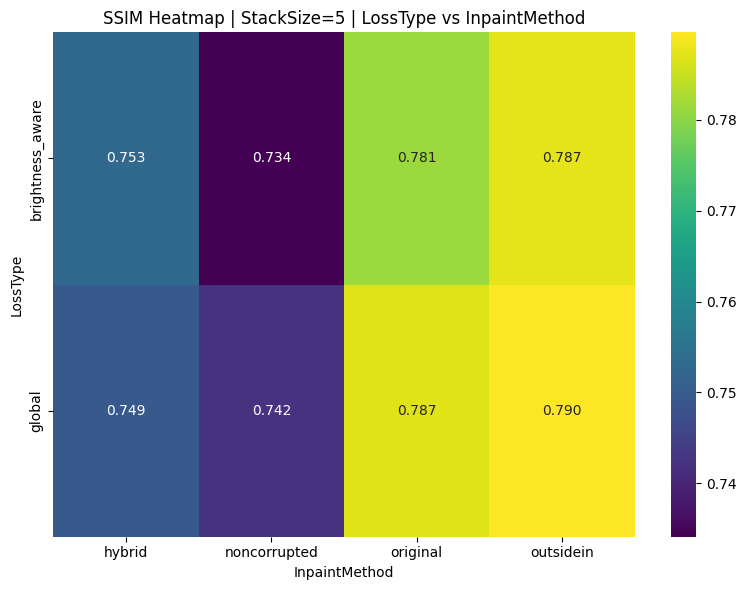

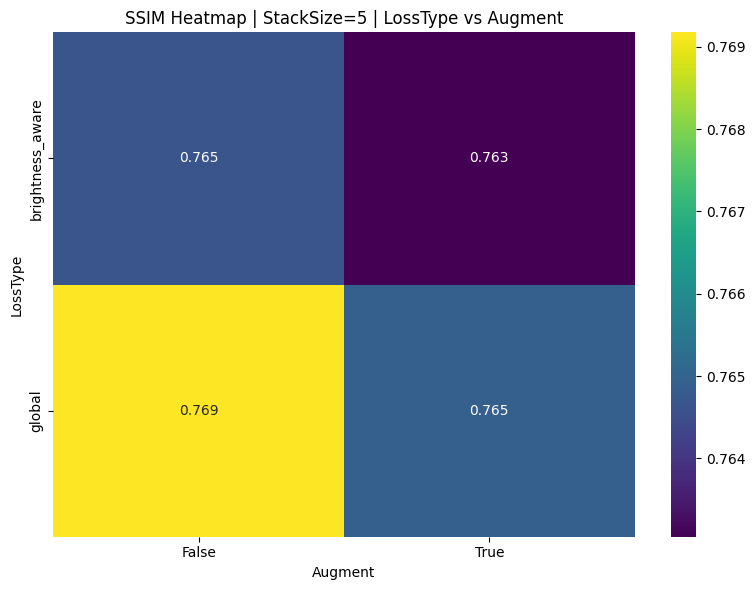

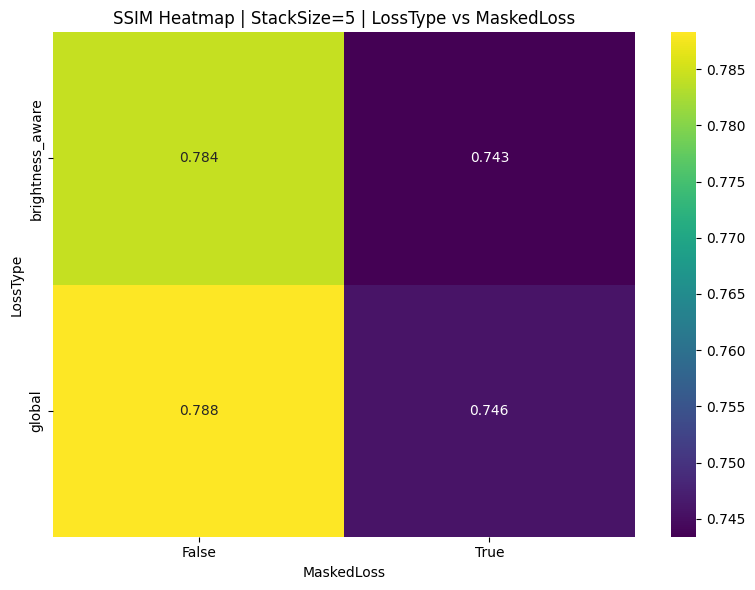

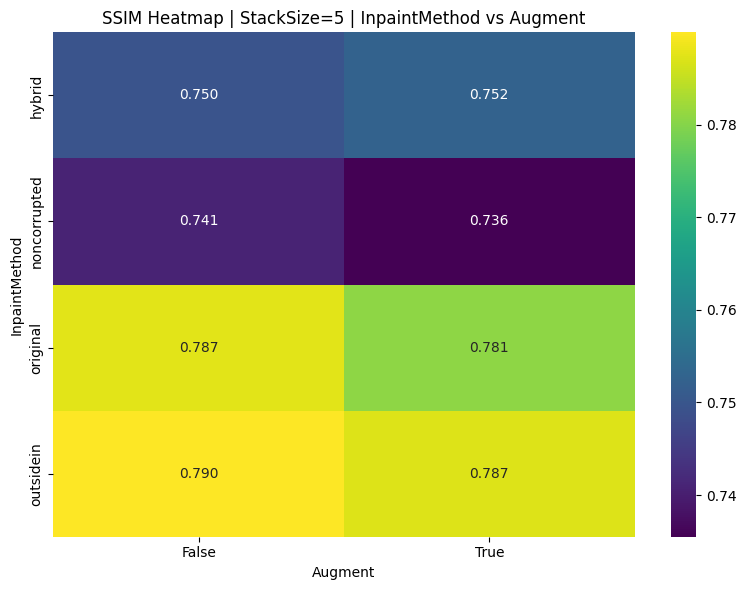

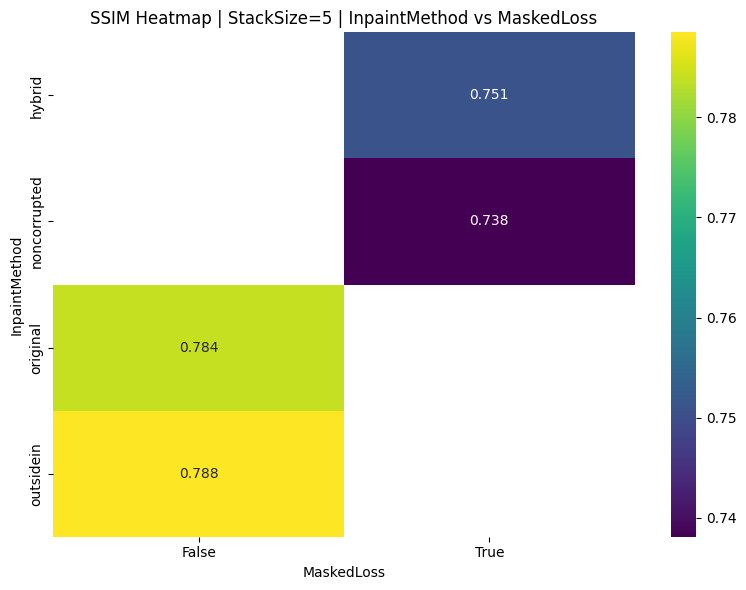

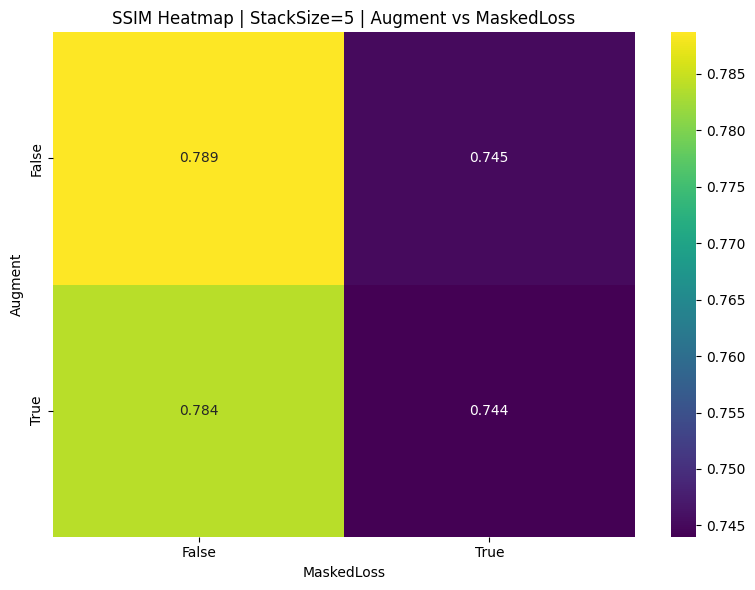

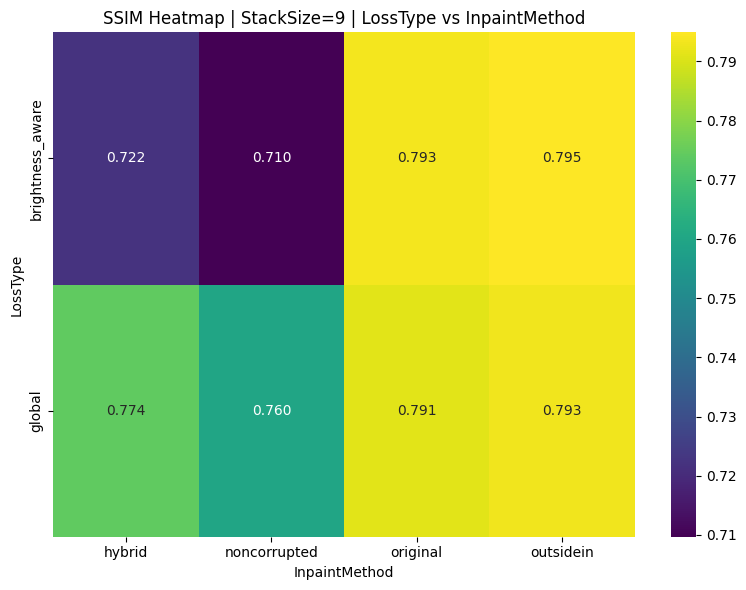

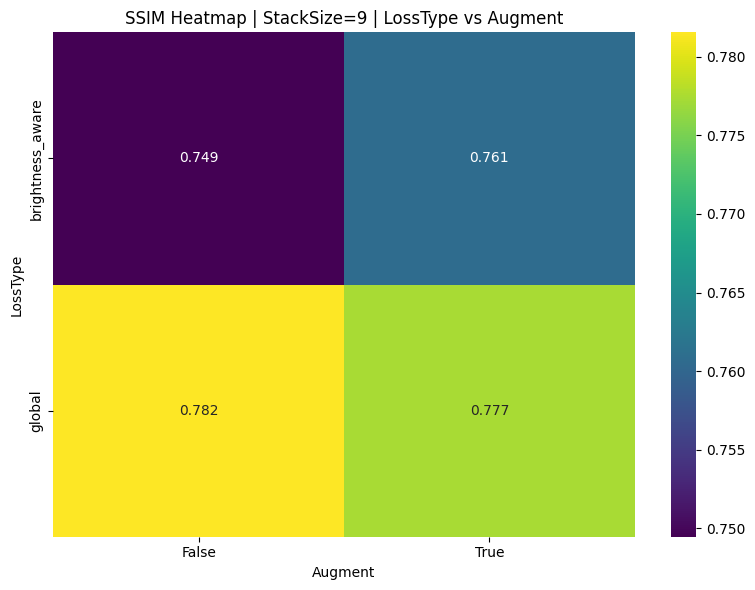

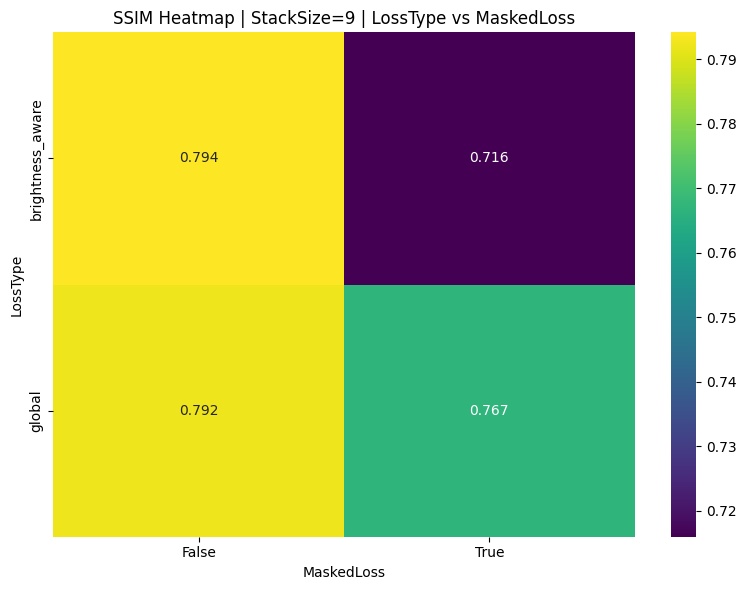

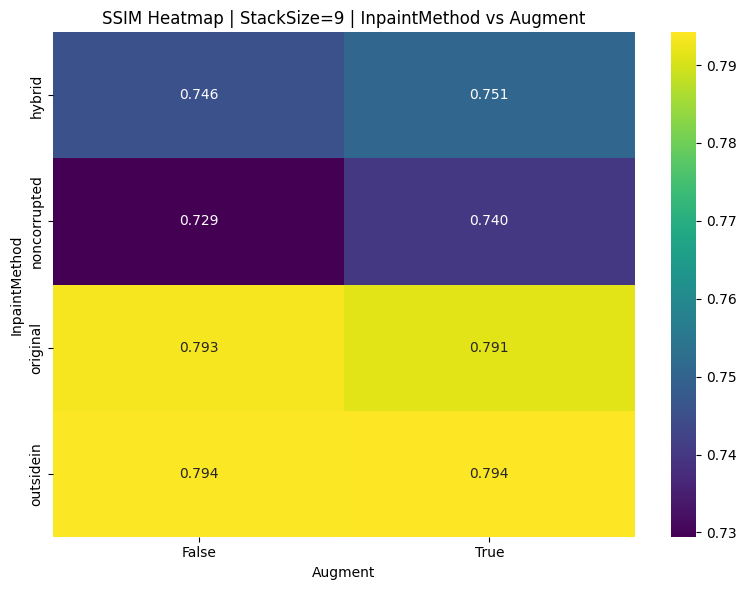

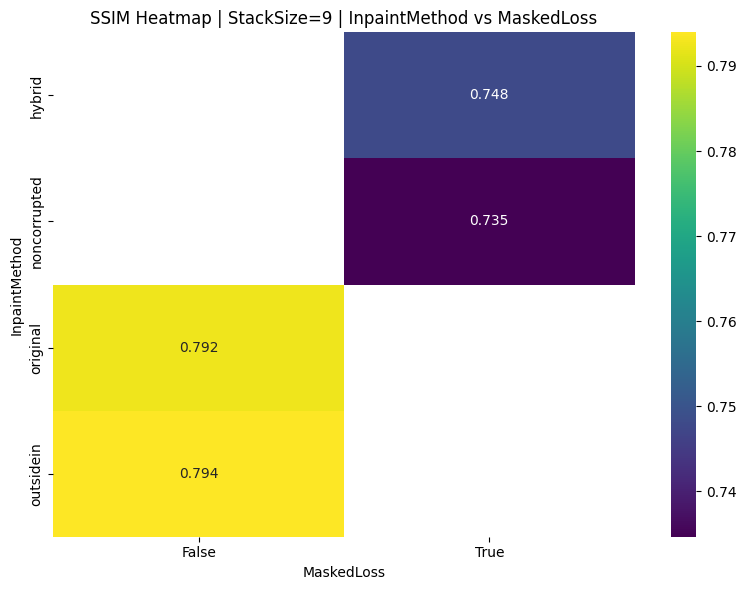

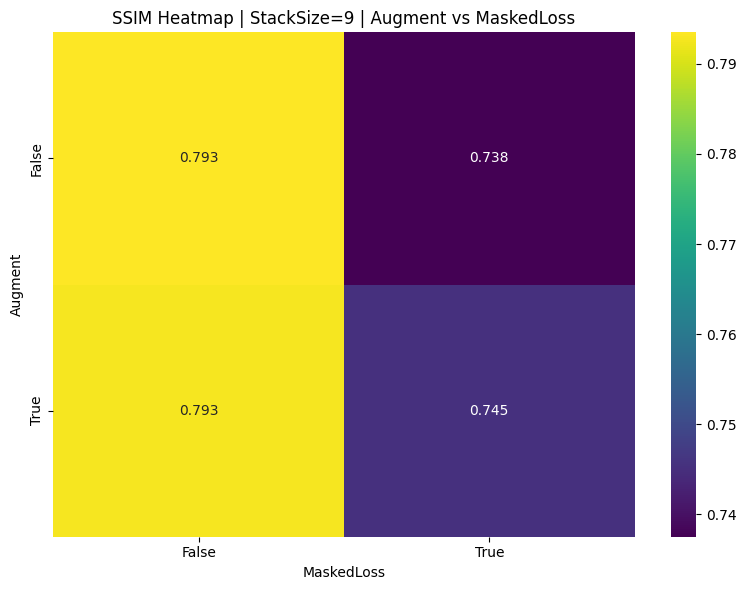

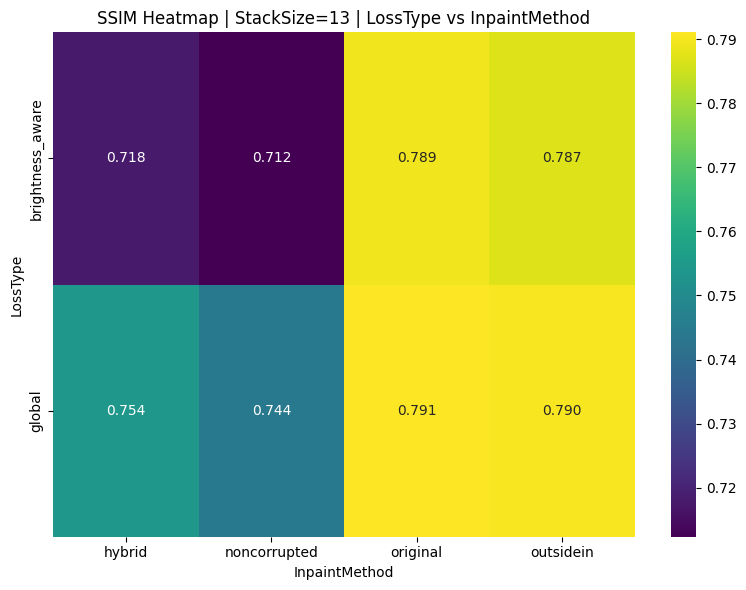

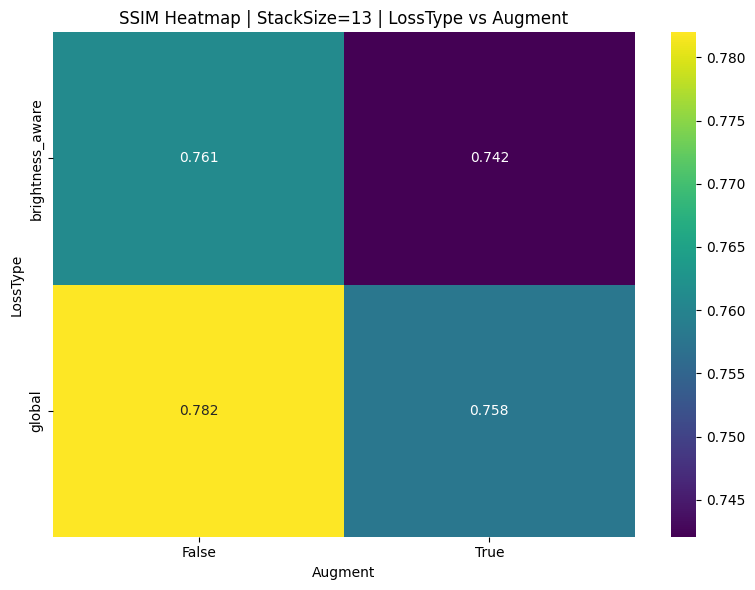

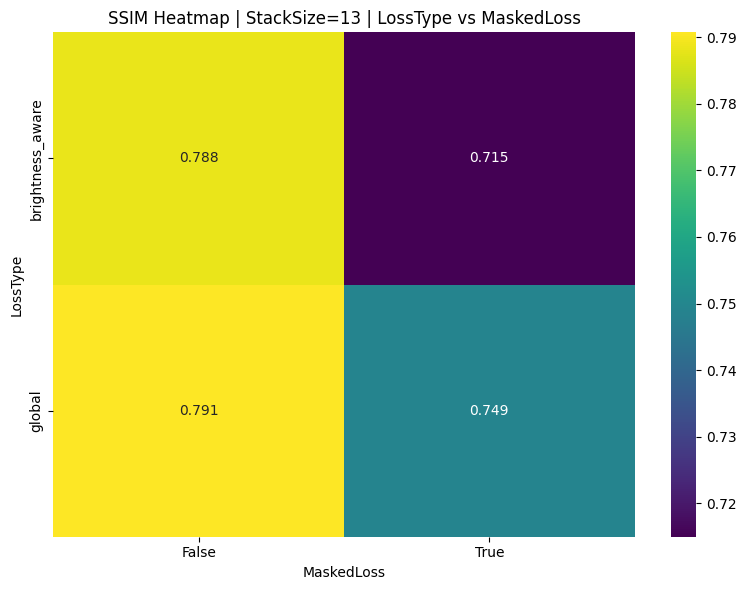

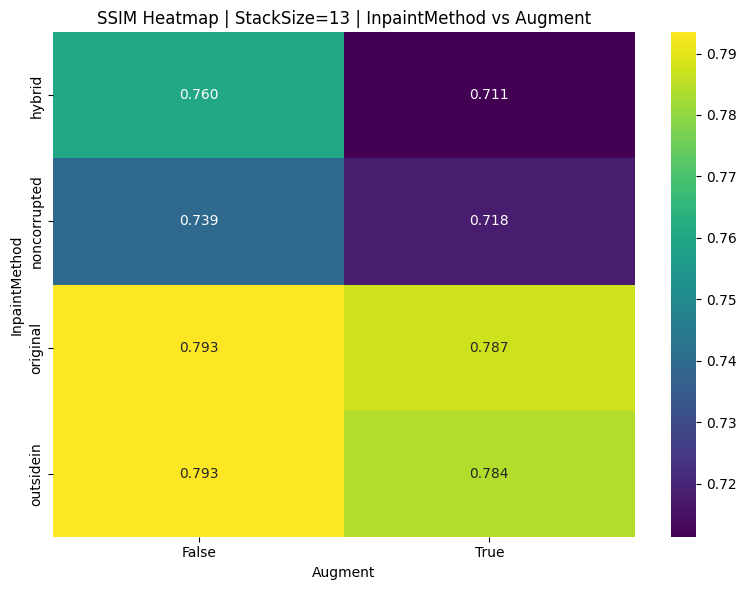

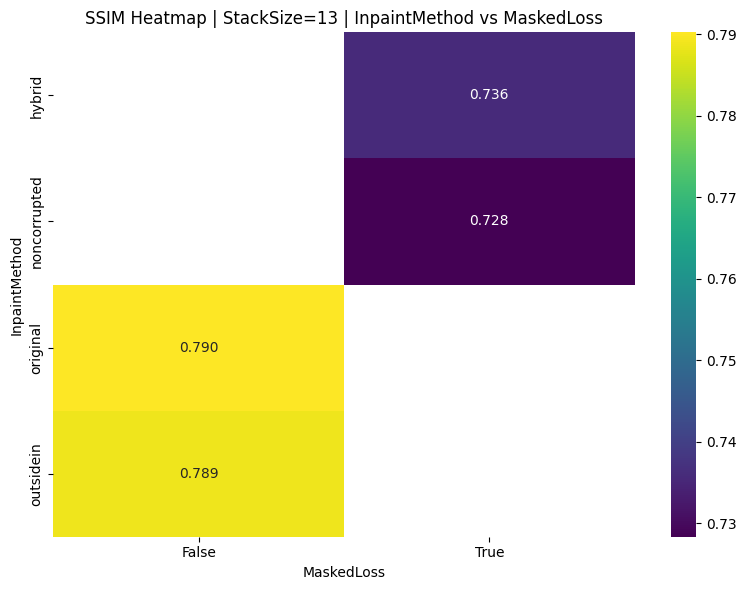

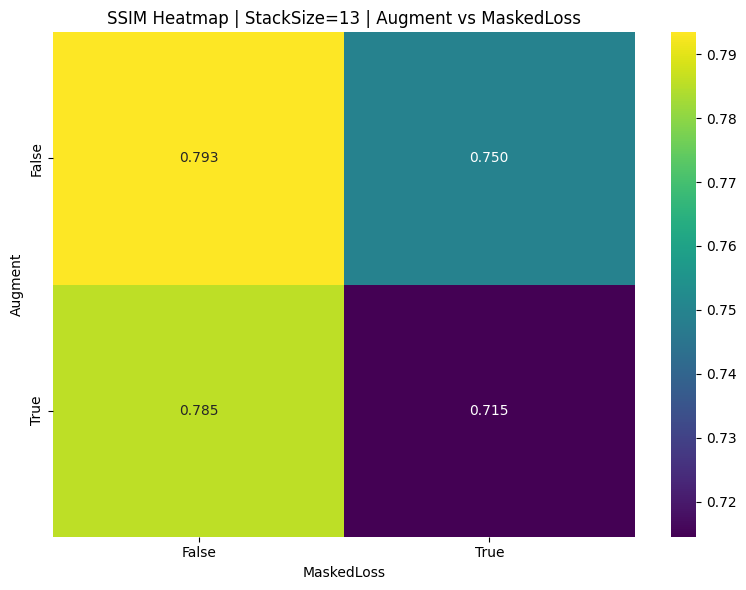

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/media/admin/Expansion/Mosaic_Data_for_Ipeks_Group/OCT_Inpainting_Testing/inpainting_ablation_metrics.csv")

# Configuration
eval_metric = "SSIM"  # Can change to "L1", "MeanIntensityError"
stack_sizes = [5, 9, 13]
combinations = [
    ("LossType", "InpaintMethod"),
    ("LossType", "Augment"),
    ("LossType", "MaskedLoss"),
    ("InpaintMethod", "Augment"),
    ("InpaintMethod", "MaskedLoss"),
    ("Augment", "MaskedLoss")
]

# Filter to fixed fold (e.g., Fold=1)
df = df[df["Fold"] == 1]

# Plot all heatmaps
for stack_size in stack_sizes:
    df_stack = df[df["StackSize"] == stack_size]

    for row_var, col_var in combinations:
        pivot = df_stack.pivot_table(
            index=row_var, columns=col_var, values=eval_metric, aggfunc="mean"
        )

        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
        plt.title(f"{eval_metric} Heatmap | StackSize={stack_size} | {row_var} vs {col_var}")
        plt.tight_layout()
        plt.show()
